<a href="https://colab.research.google.com/github/lander302/HonoursProject_new/blob/main/NewHonoursCodeGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np  # numerical computing library
import pandas as pd  # dataframes / tables

# Dataset size

rng = np.random.default_rng(42)  # random number generator with fixed seed for reproducibility
N = 6000  # number of students to generate


# Helper functions

def clip(a, lo, hi):  # define a function to cap values between lo and hi
    return np.minimum(np.maximum(a, lo), hi)

 # define sigmoid function to add non-linearity and compress extremes
def sigmoid(x):
    return 1 / (1 + np.exp(-x))  # sigmoid formula

# function to convert numeric final score to letter grade
def letter_grade(score):
    if score >= 70:  # if score is 70 or above
        return "A"  # assign A
    if score >= 60:  # if score is between 60 and 69.99
        return "B"  # assign B
    if score >= 50:  # if score is between 50 and 59.99
        return "C"  # assign C
    if score >= 40:  # if score is between 40 and 49.99
        return "D"  # assign D
    return "F"  # otherwise assign F (below 40)


# Student identity fields

student_num = np.arange(1000, 1000 + N)  # create integer IDs 1000..(1000+N-1)
Student_ID = [f"S{n}" for n in student_num]  # convert them into strings like "S1000"

first_names = np.array([  # define a list of first names to randomly sample from
    "Alex","Sam","Taylor","Jordan","Morgan","Jamie","Casey","Riley","Avery","Cameron",
    "Charlie","Drew","Finley","Harper","Hayden","Kai","Logan","Parker","Quinn","Rowan"
])

last_names = np.array([  # define a list of last names to randomly sample from
    "Smith","Jones","Brown","Taylor","Wilson","Johnson","White","Martin","Thompson","Garcia",
    "Clark","Lewis","Lee","Walker","Hall","Allen","Young","King","Wright","Scott"
])

First_Name = rng.choice(first_names, N)  # randomly assign first names (size N)
Last_Name = rng.choice(last_names, N)  # randomly assign last names (size N)

Email = [  # generate a (fake) email address for each student
    f"{fn.lower()}.{ln.lower()}{i}@university.ac.uk"
    for i, (fn, ln) in enumerate(zip(First_Name, Last_Name), start=1)
]

Gender = rng.choice(["Female", "Male"], N, p=[0.52, 0.48])  # gender with slight imbalance
Age = rng.integers(10, 18, N)  # ages 10-18 inclusive of 10 and exclusive of 18

Department = rng.choice(  # assign departments with chosen proportions
    ["CS", "Engineering", "Business", "Mathematics"],
    N,
    p=[0.28, 0.27, 0.25, 0.20]
)


# Context variables (categorical)

Internet_Access_at_Home = rng.choice(["Yes", "No"], N, p=[0.88, 0.12])  # most have internet
Family_Income_Level = rng.choice(["Low", "Medium", "High"], N, p=[0.32, 0.50, 0.18])  # income bands
Parent_Education_Level = rng.choice(  # parent education categories
    ["High School", "College", "Bachelor", "Master"],
    N,
    p=[0.28, 0.26, 0.30, 0.16]
)

Extracurricular_Activities = rng.choice(["Yes", "No"], N, p=[0.55, 0.45])  # extracurricular participation

# Introduce missingness in Parent_Education_Level to align with real world scenario
mask_missing_parent = rng.random(N) < 0.20  # 20% missing
Parent_Education_Level = Parent_Education_Level.astype(object)  # cast to object so we can insert strings
Parent_Education_Level[mask_missing_parent] = "Unknown"  # replace missing with "Unknown" (transparently)


# Latent factors (NOT stored in final dataset)
# Create "hidden" structure so the data isn't random, but also not perfectly predictable.

ability = rng.normal(0, 1, N)  # unobserved academic ability (mean 0, std 1)
motivation = rng.normal(0, 1, N)  # unobserved motivation/drive (mean 0, std 1)

# Convert categorical context into small numeric effects (subtle, not deterministic)
income_effect = np.select(  # map income to small numeric adjustments
    [Family_Income_Level == "Low", Family_Income_Level == "Medium", Family_Income_Level == "High"],
    [-0.15, 0.00, 0.10],
    default=0.0
)

internet_effect = np.where(Internet_Access_at_Home == "Yes", 0.08, -0.08)  # small boost if internet available


# Wellbeing + behaviour

# Stress: influenced by department workload + low motivation/ability + noise
base_stress = (  # baseline stress around 5
    5
    + 0.6 * (Department == "Engineering")  # engineering slightly more stressful
    + 0.4 * (Department == "CS")  # CS slightly more stressful
    + rng.normal(0, 1.2, N)  # random personal variation
)

stress_latent = (  # additional stress factors
    base_stress
    + 0.6 * (motivation < -0.5)  # low motivation linked to stress
    + 0.2 * (ability < -0.5)  # low ability linked to stress
)

Stress_Level = clip(stress_latent, 1, 10)  # clip stress to range 1–10

# Sleep: negatively related to stress, with some noise
sleep = (  # build sleep hours
    7.2
    - 0.18 * (Stress_Level - 5)  # higher stress reduces sleep
    + rng.normal(0, 0.7, N)  # random variation in sleep
)

Sleep_Hours = clip(sleep, 4.0, 9.5)  # clip sleep to realistic range

# Study hours: increases with motivation + ability, reduced by high stress, increased by sleep, plus context effects
study = (  # baseline study hours
    8
    + 3.0 * motivation  # more motivation => more study
    + 1.2 * ability  # more ability can correlate with effective studying
    + 0.7 * (Department == "CS")  # slight dept effect
    + 0.9 * (Department == "Engineering")  # slight dept effect
)

study = study + 0.6 * internet_effect + 0.3 * income_effect  # context contributes slightly
study = study + (-0.45 * (Stress_Level - 5)) + (0.35 * (Sleep_Hours - 7))  # stress hurts, sleep helps
study = study + rng.normal(0, 2.2, N)  # individual randomness

Study_Hours = clip(study, 0, 30)  # clip study hours to 0–30 per week

# Attendance: linked to motivation/ability + context, reduced by stress, improved by sleep, noisy
att = (  # baseline attendance
    82
    + 6.0 * motivation
    + 2.0 * ability
    + 1.2 * internet_effect
    + 1.0 * income_effect
)

att = att + (-1.0 * (Stress_Level - 5)) + (0.8 * (Sleep_Hours - 7))  # stress hurts, sleep helps
att = att + rng.normal(0, 6.0, N)  # randomness in attendance (everyone has different circumstances)

Attendance = clip(att, 40, 100)  # attendance between 40 and 100

# Participation: combines motivation and attendance, plus noise
participation = (  # baseline participation
    60
    + 12 * motivation  # motivation strongly affects participation
    + 0.25 * (Attendance - 80)  # attendance contributes a bit
    + rng.normal(0, 10, N)  # randomness
)

Participation = clip(participation, 0, 100)  # participation 0–100


# Formative assessments (emerge from engagement + ability + noise)

# Assignments: depend on study + motivation + ability, with noise
Assignments = 55 + 1.1 * Study_Hours + 8 * motivation + 6 * ability + rng.normal(0, 10, N)
Assignments = clip(Assignments, 0, 100)

# Quizzes: depend on study + ability, with noise
Quizzes = 50 + 0.9 * Study_Hours + 5 * motivation + 7 * ability + rng.normal(0, 11, N)
Quizzes = clip(Quizzes, 0, 100)

# Projects: depend more on ability + study, with noise
Projects = 52 + 0.8 * Study_Hours + 5 * motivation + 10 * ability + rng.normal(0, 12, N)
Projects = clip(Projects, 0, 100)

# Midterm: depends on ability + study + small attendance effect + noise
Midterm = 50 + 0.55 * Study_Hours + 0.12 * (Attendance - 80) + 10 * ability + rng.normal(0, 12, N)
Midterm = clip(Midterm, 0, 100)

# Measurement noise (realistic: inputs aren’t measured perfectly)

Attendance = clip(Attendance + rng.normal(0, 1.5, N), 40, 100)  # slight measurement noise on attendance
Study_Hours = clip(Study_Hours + rng.normal(0, 0.8, N), 0, 30)  # slight measurement noise on study hours


# Final exam score (emerges, with interaction + nonlinearity + anomalies)

exam_day_noise = rng.normal(0, 12, N)  # exam-day shock (unobserved influences)

# Interaction effect: stress hurts more when sleep is low (nonlinear realism)
stress_sleep_penalty = (Stress_Level - 5) * (7.5 - Sleep_Hours)  # penalty increases if stress high AND sleep low
stress_sleep_penalty = np.maximum(stress_sleep_penalty, 0)  # only apply penalty when sleep is below ~7.5

raw_score = (  # combine multiple factors into an unbounded score
    0.28 * Midterm
    + 0.22 * Assignments
    + 0.18 * Quizzes
    + 0.22 * Projects
    + 0.06 * Participation
    + 0.04 * Attendance
    - 1.0 * stress_sleep_penalty
    + exam_day_noise
)

# Nonlinearity: compress extremes so the relationship isn't "too perfect"
Final_Score = 100 * sigmoid((raw_score - 55) / 12)  # map raw_score into 0–100 smoothly

Final_Score = clip(Final_Score, 0, 100)  # ensure final score stays in bounds

# Rare anomalies: bad day / illness / panic can drop scores even for strong students
p_bad_day = 0.02  # 2% of students have a bad exam day
bad_day = rng.random(N) < p_bad_day  # boolean mask for bad day students
Final_Score[bad_day] = clip(Final_Score[bad_day] - rng.uniform(20, 60, bad_day.sum()), 0, 100)  # reduce their score

# Rare anomalies: a small number outperform expectation (lucky questions / knowledge)
p_lucky = 0.01  # 1% have a lucky day
lucky = rng.random(N) < p_lucky  # boolean mask for lucky day students
Final_Score[lucky] = clip(Final_Score[lucky] + rng.uniform(10, 25, lucky.sum()), 0, 100)  # boost their score

# Total score: for dashboard summary only (will not be used to predict final score to avoid leakage)
Total_Score = (  # compute a weighted overall performance indicator
    0.15 * Attendance
    + 0.20 * Midterm
    + 0.20 * Assignments
    + 0.15 * Quizzes
    + 0.20 * Projects
    + 0.10 * Participation
)

Total_Score = clip(Total_Score, 0, 100)  # keep it within 0–100

Grade = [letter_grade(s) for s in Final_Score]  # convert final score into letter grades


# Assemble final dataframe (matches columns from example datasets and preliminary question answers)

df = pd.DataFrame({  # create the final dataset as a DataFrame
    "Student_ID": Student_ID,  # unique student identifier
    "First_Name": First_Name,  # first name
    "Last_Name": Last_Name,  # last name
    "Email": Email,  # email address
    "Gender": Gender,  # gender
    "Age": Age,  # age
    "Department": Department,  # department
    "Attendance (%)": np.round(Attendance, 2),  # attendance percentage (rounded)
    "Midterm_Score": np.round(Midterm, 2),  # midterm score
    "Final_Score": np.round(Final_Score, 2),  # final exam score
    "Assignments_Avg": np.round(Assignments, 2),  # assignments average
    "Quizzes_Avg": np.round(Quizzes, 2),  # quizzes average
    "Participation_Score": np.round(Participation, 2),  # participation score
    "Projects_Score": np.round(Projects, 2),  # projects score
    "Total_Score": np.round(Total_Score, 2),  # total score indicator (dashboard only)
    "Grade": Grade,  # letter grade
    "Study_Hours_per_Week": np.round(Study_Hours, 2),  # study hours per week
    "Extracurricular_Activities": Extracurricular_Activities,  # extracurricular yes/no
    "Internet_Access_at_Home": Internet_Access_at_Home,  # internet access yes/no
    "Parent_Education_Level": Parent_Education_Level,  # parent education level (with Unknown)
    "Family_Income_Level": Family_Income_Level,  # family income level
    "Stress_Level (1-10)": np.round(Stress_Level, 0).astype(int),  # stress level 1–10 (int)
    "Sleep_Hours_per_Night": np.round(Sleep_Hours, 2),  # sleep hours per night
})

print("Synthetic dataset created:", df.shape)
display(df.head())

out_path = "synthetic_students_performance.csv"
df.to_csv(out_path, index=False)  # save CSV for Power BI and ML
print("Saved:", out_path)  # confirm save location


Synthetic dataset created: (6000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Sam,Lee,sam.lee1@university.ac.uk,Female,17,Engineering,78.92,42.22,33.11,...,58.62,59.58,F,5.65,No,Yes,High School,Medium,5,6.80
1,S1001,Kai,Young,kai.young2@university.ac.uk,Female,14,CS,100.00,64.58,90.47,...,65.56,75.59,A,8.49,No,Yes,College,Medium,6,7.65
2,S1002,Harper,Lee,harper.lee3@university.ac.uk,Male,14,Engineering,84.98,68.59,65.50,...,54.39,68.23,B,9.35,Yes,Yes,Bachelor,Medium,8,5.93
3,S1003,Avery,Lewis,avery.lewis4@university.ac.uk,Female,12,Mathematics,98.95,55.42,94.17,...,77.71,75.92,A,10.70,Yes,Yes,Unknown,Low,6,7.04
4,S1004,Avery,Garcia,avery.garcia5@university.ac.uk,Female,17,Engineering,98.75,54.81,49.07,...,73.69,74.88,D,14.57,No,Yes,Master,Low,5,6.78


Saved: synthetic_students_performance.csv


#**Cleaning**

In [ ]:
# Make sure all colunms are created
df.isna().sum()
df.dtypes


,0
Student_ID,object
First_Name,object
Last_Name,object
Email,object
Gender,object
Age,int64
Department,object
Attendance (%),float64
Midterm_Score,float64
Final_Score,float64


In [ ]:
df[['Attendance (%)','Final_Score','Study_Hours_per_Week']].describe()

,Attendance (%),Final_Score,Study_Hours_per_Week
count,6000.000000,6000.00000,6000.000000
mean,81.435463,55.07805,8.253515
std,8.933679,26.66284,4.084841
min,49.560000,0.00000,0.000000
25%,75.257500,33.40000,5.460000
50%,81.370000,57.31000,8.165000
75%,87.720000,78.21250,11.090000
max,100.000000,100.00000,24.580000


# **EDA**

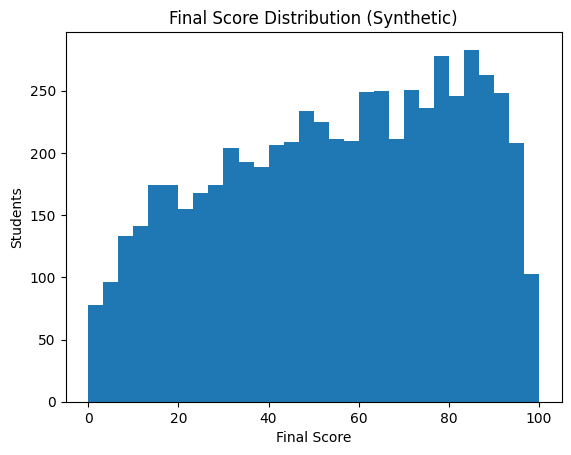

,Attendance (%),Midterm_Score,Assignments_Avg,Quizzes_Avg,Projects_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night,Final_Score
Attendance (%),1.000000,0.278513,0.552896,0.440069,0.429434,0.608483,-0.267233,0.141603,0.421640
Midterm_Score,0.278513,1.000000,0.397046,0.413252,0.460041,0.349832,-0.089525,0.044201,0.506833
Assignments_Avg,0.552896,0.397046,1.000000,0.548244,0.556336,0.707769,-0.154167,0.065254,0.562012
Quizzes_Avg,0.440069,0.413252,0.548244,1.000000,0.521965,0.581535,-0.127713,0.044143,0.522949
Projects_Score,0.429434,0.460041,0.556336,0.521965,1.000000,0.558560,-0.120167,0.064746,0.566592
Study_Hours_per_Week,0.608483,0.349832,0.707769,0.581535,0.558560,1.000000,-0.255180,0.134312,0.508637
Stress_Level (1-10),-0.267233,-0.089525,-0.154167,-0.127713,-0.120167,-0.255180,1.000000,-0.297777,-0.168099
Sleep_Hours_per_Night,0.141603,0.044201,0.065254,0.044143,0.064746,0.134312,-0.297777,1.000000,0.087915
Final_Score,0.421640,0.506833,0.562012,0.522949,0.566592,0.508637,-0.168099,0.087915,1.000000


,Final_Score
Department,
Business,54.662890
CS,55.571364
Engineering,55.896397
Mathematics,53.911090


,Final_Score
Gender,
Female,55.442840
Male,54.689401


,Final_Score
Internet_Access_at_Home,
No,53.979639
Yes,55.214734


In [ ]:
import matplotlib.pyplot as plt

# Histogram
plt.hist(df["Final_Score"], bins=30)
plt.title("Final Score Distribution (Synthetic)")
plt.xlabel("Final Score")
plt.ylabel("Students")
plt.show()

eda_features = [
    "Attendance (%)","Midterm_Score","Assignments_Avg","Quizzes_Avg","Projects_Score",
    "Study_Hours_per_Week","Stress_Level (1-10)","Sleep_Hours_per_Night","Final_Score"
]
display(df[eda_features].corr())

display(df.groupby("Department")["Final_Score"].mean())
display(df.groupby("Gender")["Final_Score"].mean())
display(df.groupby("Internet_Access_at_Home")["Final_Score"].mean())


In [ ]:
df['At_Risk_Low']  = (df['Final_Score'] < 45).astype(int)
df['At_Risk_High'] = (df['Final_Score'] < 55).astype(int)


In [ ]:
# fair and transparent
# Risk was defined relative to cohort performance rather than fixed grade boundaries.
df['At_Risk_30pct'] = (df['Final_Score'] < df['Final_Score'].quantile(0.30)).astype(int)
df['At_Risk_50pct'] = (df['Final_Score'] < df['Final_Score'].quantile(0.50)).astype(int)

Machine Learning Algorithms

Define risks fairly for students results

High risk will be made the more important

In [ ]:
# Choosn two risk levels based on cohort distribution
high_risk_cutoff = df['Final_Score'].quantile(0.30)   # bottom 30%
early_risk_cutoff = df['Final_Score'].quantile(0.50) # bottom 50%

high_risk_cutoff, early_risk_cutoff


(np.float64(38.47), np.float64(57.31))

In [ ]:
df['High_Risk'] = (df['Final_Score'] < high_risk_cutoff).astype(int)
df['Early_Risk'] = (df['Final_Score'] < early_risk_cutoff).astype(int)


Selecting features that will be used for the predicitons to be made

In [ ]:
# Feature selection for high risk
features = [
    'Attendance (%)',
    'Midterm_Score',
    'Assignments_Avg',
    'Quizzes_Avg',
    'Projects_Score',
    'Participation_Score',
    'Study_Hours_per_Week',
    'Stress_Level (1-10)',
    'Sleep_Hours_per_Night'
]

X = df[features]
y = df['High_Risk']


Split, train and test data

In [ ]:
# Split for training
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Imports for algorithms

In [ ]:
# Imports
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix



In [ ]:
model_results = []  # stores metrics for each tuned model
best_models = {}    # stores the best estimator for each model name

Logistic regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Model: Logistic Regression (baseline linear classifier)
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Small, justified grid: regularisation strength
param_grid_lr = {"model__C": [0.1, 0.5, 1, 2, 5]}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring="roc_auc", n_jobs=-1)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
best_models["Logistic Regression (tuned)"] = best_lr

print("LR best params:", grid_lr.best_params_)
print("LR CV ROC-AUC:", grid_lr.best_score_)

# Test metrics
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\nLR TEST METRICS")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("ROC AUC  :", auc)
print("Confusion Matrix:\n", cm)

model_results.append({
    "Model": "Logistic Regression (tuned)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "ROC_AUC": auc
})


LR best params: {'model__C': 0.1}
LR CV ROC-AUC: 0.8395899583553609

LR TEST METRICS
Accuracy : 0.7691666666666667
Precision: 0.587737843551797
Recall   : 0.7722222222222223
F1       : 0.6674669867947179
ROC AUC  : 0.8573015873015873
Confusion Matrix:
 [[645 195]
 [ 82 278]]


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Model: Random Forest (non-linear, bagging ensemble)
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Small grid: controls complexity & overfitting
param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 16],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
best_models["Random Forest (tuned)"] = best_rf

print("RF best params:", grid_rf.best_params_)
print("RF CV ROC-AUC:", grid_rf.best_score_)

# Test metrics
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\nRF TEST METRICS")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("ROC AUC  :", auc)
print("Confusion Matrix:\n", cm)

model_results.append({
    "Model": "Random Forest (tuned)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "ROC_AUC": auc
})


RF best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}
RF CV ROC-AUC: 0.8310021981623545

RF TEST METRICS
Accuracy : 0.7825
Precision: 0.627906976744186
Recall   : 0.675
F1       : 0.6506024096385542
ROC AUC  : 0.8496230158730158
Confusion Matrix:
 [[696 144]
 [117 243]]


Gradient Boost Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Model: Gradient Boosting (boosting ensemble)
gb = GradientBoostingClassifier(random_state=42)

# Small grid: learning rate + number of estimators + tree depth
param_grid_gb = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring="roc_auc", n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
best_models["Gradient Boosting (tuned)"] = best_gb

print("GB best params:", grid_gb.best_params_)
print("GB CV ROC-AUC:", grid_gb.best_score_)

# Test metrics
y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\nGB TEST METRICS")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("ROC AUC  :", auc)
print("Confusion Matrix:\n", cm)

model_results.append({
    "Model": "Gradient Boosting (tuned)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "ROC_AUC": auc
})


GB best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
GB CV ROC-AUC: 0.8350821614786321

GB TEST METRICS
Accuracy : 0.7966666666666666
Precision: 0.7283464566929134
Recall   : 0.5138888888888888
F1       : 0.6026058631921825
ROC AUC  : 0.853166335978836
Confusion Matrix:
 [[771  69]
 [175 185]]


In [ ]:
results_df = pd.DataFrame(model_results)
display(results_df.sort_values("ROC_AUC", ascending=False))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (tuned),0.769167,0.587738,0.772222,0.667467,0.857302
2,Gradient Boosting (tuned),0.796667,0.728346,0.513889,0.602606,0.853166
1,Random Forest (tuned),0.782500,0.627907,0.675000,0.650602,0.849623


In [ ]:
# Final model chosen for dashboard (early-warning priority = high recall)
final_model = best_lr  # or best_rf / best_gb if you decide differently

# Train on all available data so every student gets a risk score
final_model.fit(X, y)

# Probability that the student is in the "High_Risk" class (bottom 30% final outcomes)
df["Risk_Probability"] = final_model.predict_proba(X)[:, 1]

# Teacher-friendly labels (ethical)
df["Risk_Band"] = pd.cut(
    df["Risk_Probability"],
    bins=[-0.001, 0.33, 0.66, 1.001],
    labels=["Low", "Medium", "High"]
)

# student display name for Power BI tables/slicers
df["Student_Name"] = df["First_Name"] + " " + df["Last_Name"]

df[["Student_ID", "Student_Name", "Department", "Risk_Probability", "Risk_Band"]].head()




,Student_ID,Student_Name,Department,Risk_Probability,Risk_Band
0,S1000,Sam Lee,Engineering,0.499022,Medium
1,S1001,Kai Young,CS,0.097450,Low
2,S1002,Harper Lee,Engineering,0.270669,Low
3,S1003,Avery Lewis,Mathematics,0.107884,Low
4,S1004,Avery Garcia,Engineering,0.107045,Low


In [ ]:
# # Add time dimension for Power BI based off of teachers input

# start_date = pd.to_datetime("2025-01-01")

# df["Assessment_Date"] = start_date + pd.to_timedelta(
#     np.random.randint(0, 84, size=len(df)), unit="D"
# )

In [ ]:
# Save the dataset Power BI will import
df.to_csv("students_with_predictions.csv", index=False)

print("Saved Power BI file: students_with_predictions.csv")

Saved Power BI file: students_with_predictions.csv
